In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('vehicledata.csv')
df

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48113000100,Census Tract 1; Dallas County; Texas,2344,324,2.9,3.5,5.2,3.4,35.7,8.8,...,25,16.8,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48113000201,Census Tract 2.01; Dallas County; Texas,1680,213,0,2.9,6.8,6.5,51.3,6,...,19.3,15.1,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48113000202,Census Tract 2.02; Dallas County; Texas,2419,388,0,2,16,9.2,56.6,8.5,...,2.6,3.4,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48113000300,Census Tract 3; Dallas County; Texas,2623,425,0,1.9,2.1,2,77.3,6,...,6.2,6.3,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,1400000US48113021100,Census Tract 211; Dallas County; Texas,1793,548,11.5,9.1,3.5,2.3,31.2,12.1,...,0,31,(X),(X),(X),(X),(X),(X),(X),(X)
642,1400000US48113021200,Census Tract 212; Dallas County; Texas,2592,703,2.2,1.9,15.8,7.6,38.7,10.9,...,100,100,(X),(X),(X),(X),(X),(X),(X),(X)
643,1400000US48113980000,Census Tract 9800; Dallas County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
644,1400000US48113980100,Census Tract 9801; Dallas County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)


# Mobility Mapping

In [4]:
import shapely
import numpy as np
import fiona
#%pip install --upgrade geopandas shapely
#%pip install --upgrade geopandas fiona

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [6]:
#Dallas County SHP file 
gdf = gpd.read_file("tl_2024_48_tract.zip")

In [7]:
import zipfile

with zipfile.ZipFile("tl_2024_48_tract.zip", "r") as zip_ref:
    zip_ref.extractall("tl_2024_48_tract")

In [8]:
dallas = gdf[gdf["COUNTYFP"] == "113"]

In [10]:
#merging
merged = dallas.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [17]:
#for now, I am seeing looking at no vehicle
df_subset = df[[
    "GEO_ID",
    "S0802_C01_094E"
]]

In [18]:
df_subset

,GEO_ID,S0802_C01_094E
0,Geography,Estimate!!Total!!Workers 16 years and over in ...
1,1400000US48113000100,2.1
2,1400000US48113000201,0
3,1400000US48113000202,0.3
4,1400000US48113000300,0.6
...,...,...
641,1400000US48113021100,0.7
642,1400000US48113021200,0
643,1400000US48113980000,-
644,1400000US48113980100,-


In [19]:
merged["S0802_C01_094E"] = pd.to_numeric(
    merged["S0802_C01_094E"],
    errors="coerce"
)

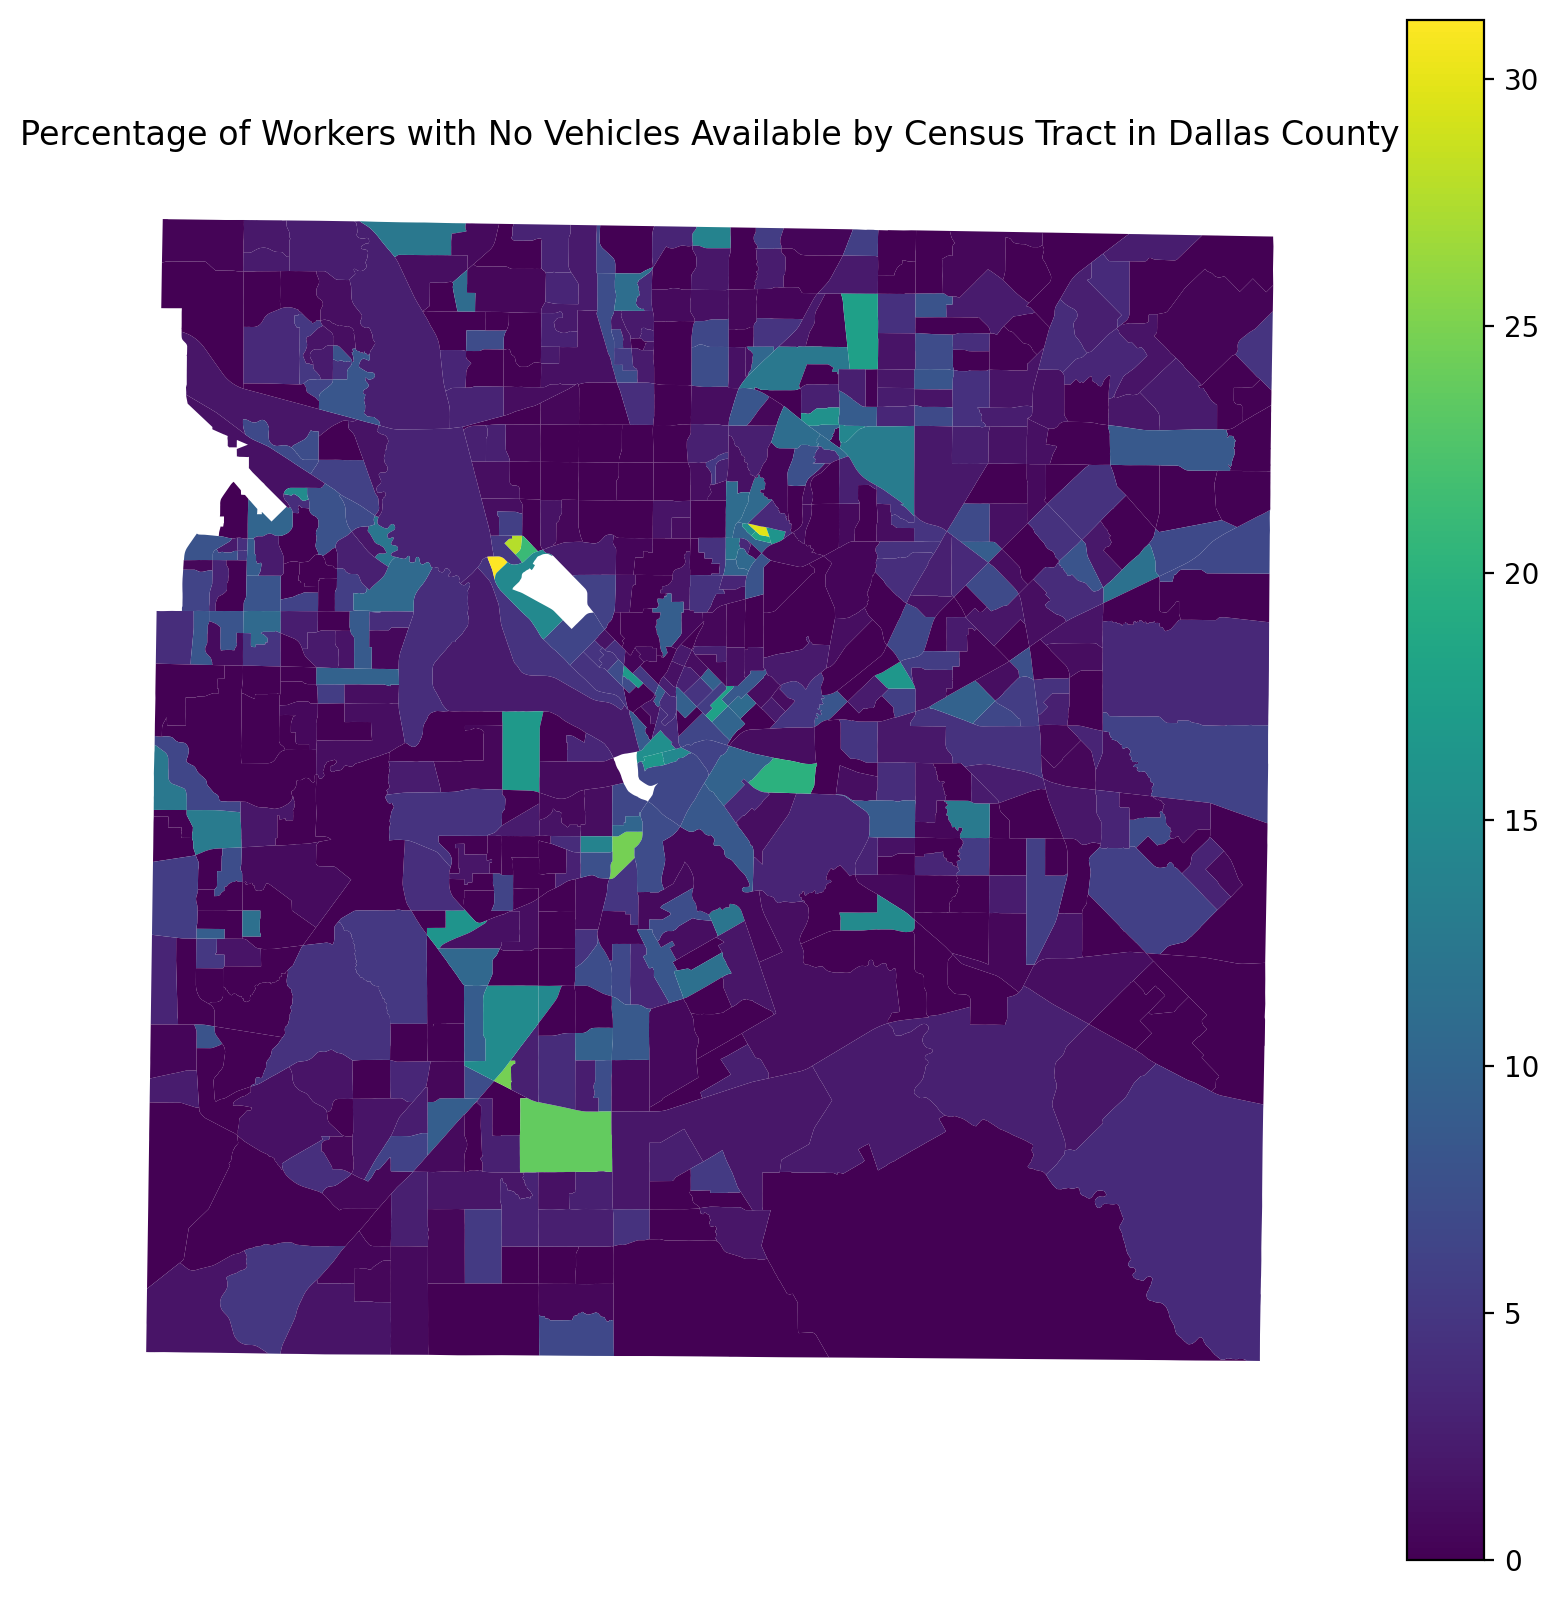

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S0802_C01_094E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Dallas County")
plt.axis("off")
plt.show()